# Day 2 — Classification & Model Evaluation

This notebook accompanies the Day 2 lecture slides. We'll build classification models and learn how to properly evaluate them.

**What we'll cover:**
1. Logistic Regression
2. Confusion Matrix & Classification Metrics
3. Decision Trees
4. K-Nearest Neighbors
5. Model Comparison
6. Overfitting, Learning Curves & Cross-Validation
7. Precision-Recall Tradeoff
8. Practice Exercises

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer, load_iris
from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold, learning_curve
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_curve, roc_auc_score, precision_recall_curve
)
import warnings
warnings.filterwarnings('ignore')

sns.set_style('darkgrid')
%matplotlib inline

np.random.seed(42)
print('All libraries loaded successfully!')

All libraries loaded successfully!


---
## 1. Logistic Regression

Despite its name, logistic regression is a **classification** algorithm. It predicts the probability that a data point belongs to a class.

### 1.1 Load the Breast Cancer Dataset

Task: Predict whether a tumor is **malignant** (cancerous) or **benign** (not cancerous) based on cell measurements.

In [2]:
# Load the breast cancer dataset
cancer = load_breast_cancer()
X = cancer.data
y = cancer.target  # 0 = malignant, 1 = benign

print(f"Dataset shape: {X.shape}")
print(f"Features: {cancer.feature_names[:5]}... ({len(cancer.feature_names)} total)")
print(f"Target classes: {cancer.target_names}")
print(f"\nClass distribution:")
unique, counts = np.unique(y, return_counts=True)
for cls, name, count in zip(unique, cancer.target_names, counts):
    print(f"  {name}: {count} ({count/len(y)*100:.1f}%)")

Dataset shape: (569, 30)
Features: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness']... (30 total)
Target classes: ['malignant' 'benign']

Class distribution:
  malignant: 212 (37.3%)
  benign: 357 (62.7%)


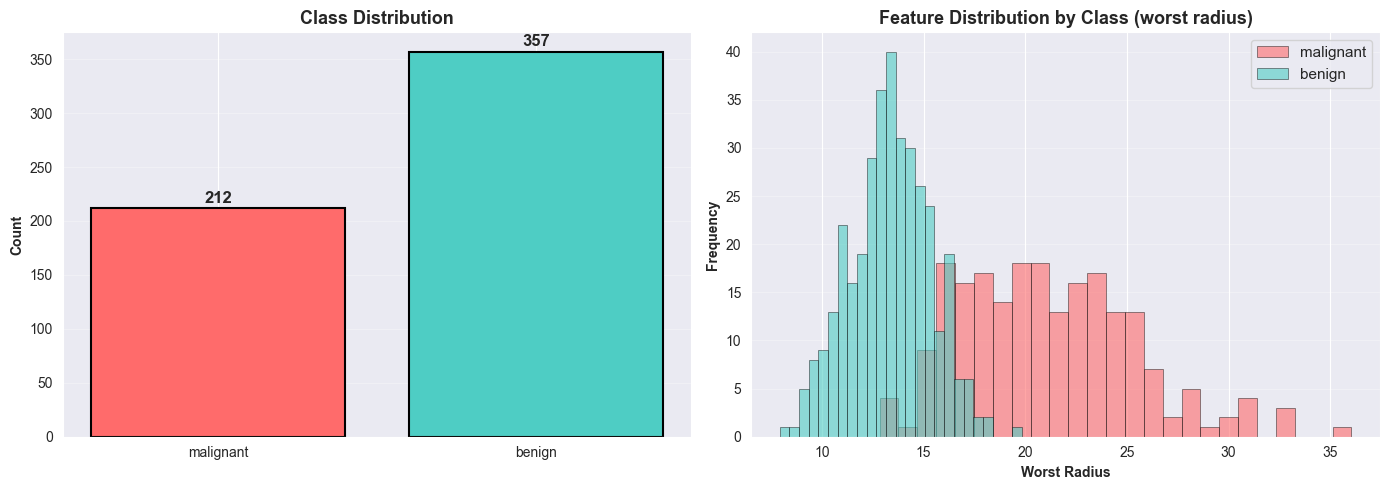

In [3]:
# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Class balance
colors = ['#FF6B6B', '#4ECDC4']
axes[0].bar(cancer.target_names, counts, color=colors, edgecolor='black', linewidth=1.5)
for i, (name, count) in enumerate(zip(cancer.target_names, counts)):
    axes[0].text(i, count + 5, f'{count}', ha='center', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Count', fontweight='bold')
axes[0].set_title('Class Distribution', fontweight='bold', fontsize=13)
axes[0].grid(axis='y', alpha=0.3)

# Feature distribution example (worst radius)
feature_idx = list(cancer.feature_names).index('worst radius')
for cls, name, color in zip([0, 1], cancer.target_names, colors):
    axes[1].hist(X[y == cls, feature_idx], bins=25, alpha=0.6,
                 color=color, label=name, edgecolor='black', linewidth=0.5)
axes[1].set_xlabel('Worst Radius', fontweight='bold')
axes[1].set_ylabel('Frequency', fontweight='bold')
axes[1].set_title('Feature Distribution by Class (worst radius)', fontweight='bold', fontsize=13)
axes[1].legend(fontsize=11)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [4]:
# Train/test split (stratified to preserve class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")

Training set: 455 samples
Test set:     114 samples


In [5]:
# Fit Logistic Regression
log_reg = LogisticRegression(max_iter=10000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

# Predictions
y_pred_lr = log_reg.predict(X_test_scaled)
y_proba_lr = log_reg.predict_proba(X_test_scaled)

print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"\nFirst 10 predictions vs actual:")
comparison = pd.DataFrame({
    'Actual': [cancer.target_names[i] for i in y_test[:10]],
    'Predicted': [cancer.target_names[i] for i in y_pred_lr[:10]],
    'P(malignant)': y_proba_lr[:10, 0].round(3),
    'P(benign)': y_proba_lr[:10, 1].round(3),
    'Correct?': ['Yes' if a == p else 'NO' for a, p in zip(y_test[:10], y_pred_lr[:10])]
})
comparison

Accuracy: 0.9825

First 10 predictions vs actual:


,Actual,Predicted,P(malignant),P(benign),Correct?
0,malignant,malignant,1.000,0.000,Yes
1,benign,benign,0.000,1.000,Yes
2,malignant,malignant,0.994,0.006,Yes
3,benign,benign,0.466,0.534,Yes
4,malignant,malignant,1.000,0.000,Yes
5,benign,benign,0.008,0.992,Yes
6,benign,benign,0.000,1.000,Yes
7,malignant,malignant,1.000,0.000,Yes
8,malignant,malignant,1.000,0.000,Yes
9,malignant,malignant,1.000,0.000,Yes


---
## 2. The Confusion Matrix & Classification Metrics

Accuracy alone can be misleading! The confusion matrix shows us exactly where the model succeeds and fails.

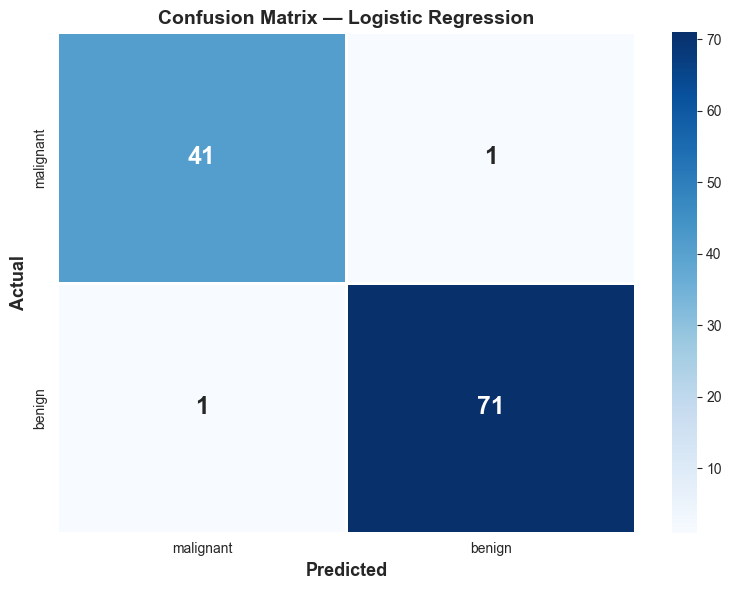

True Negatives (correctly predicted malignant):  41
False Positives (malignant predicted as benign): 1
False Negatives (benign predicted as malignant): 1
True Positives (correctly predicted benign):     71


In [6]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=cancer.target_names,
            yticklabels=cancer.target_names,
            linewidths=2, linecolor='white',
            annot_kws={'size': 18, 'fontweight': 'bold'})
plt.xlabel('Predicted', fontsize=13, fontweight='bold')
plt.ylabel('Actual', fontsize=13, fontweight='bold')
plt.title('Confusion Matrix — Logistic Regression', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives (correctly predicted malignant):  {tn}")
print(f"False Positives (malignant predicted as benign): {fp}")
print(f"False Negatives (benign predicted as malignant): {fn}")
print(f"True Positives (correctly predicted benign):     {tp}")

In [7]:
# Full Classification Report
print("=" * 55)
print("CLASSIFICATION REPORT")
print("=" * 55)
print(classification_report(y_test, y_pred_lr, target_names=cancer.target_names))

print("\nWhat each metric means for cancer detection:")
print(f"  Precision (malignant): When we say 'cancer', we're right {precision_score(y_test, y_pred_lr, pos_label=0)*100:.1f}% of the time")
print(f"  Recall (malignant):    We catch {recall_score(y_test, y_pred_lr, pos_label=0)*100:.1f}% of actual cancer cases")
print(f"  F1 (malignant):        Overall balance = {f1_score(y_test, y_pred_lr, pos_label=0):.4f}")

CLASSIFICATION REPORT
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


What each metric means for cancer detection:
  Precision (malignant): When we say 'cancer', we're right 97.6% of the time
  Recall (malignant):    We catch 97.6% of actual cancer cases
  F1 (malignant):        Overall balance = 0.9762


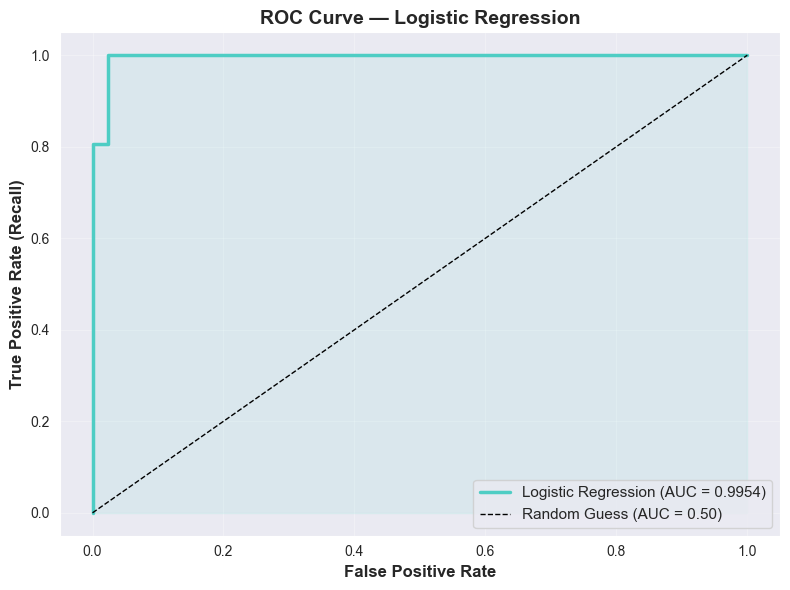

In [8]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba_lr[:, 1])
auc_score = roc_auc_score(y_test, y_proba_lr[:, 1])

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#4ECDC4', linewidth=2.5, label=f'Logistic Regression (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Guess (AUC = 0.50)')
plt.fill_between(fpr, tpr, alpha=0.1, color='#4ECDC4')
plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate (Recall)', fontsize=12, fontweight='bold')
plt.title('ROC Curve — Logistic Regression', fontsize=14, fontweight='bold')
plt.legend(fontsize=11, loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## 3. Decision Trees

Decision trees learn if/else rules from data. They're highly interpretable — you can see exactly WHY the model made each decision.

Decision Tree Accuracy: 0.9386


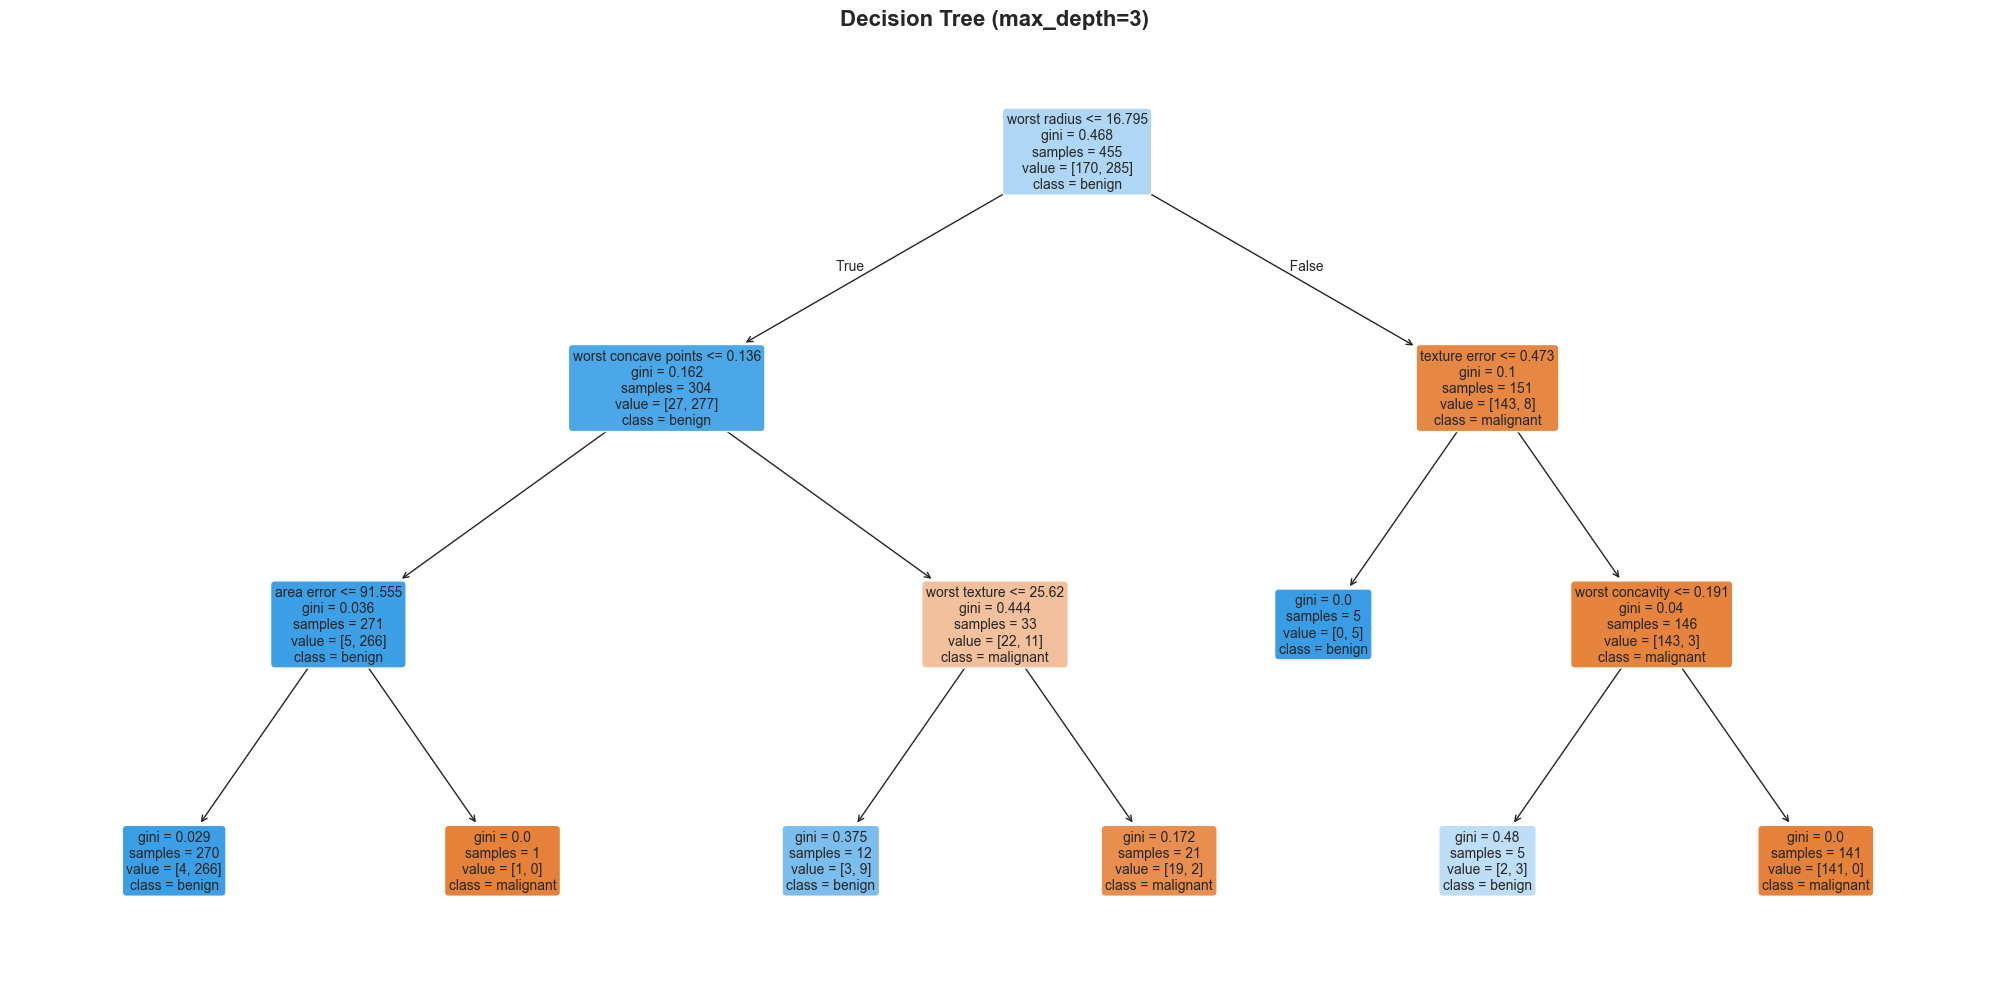

In [9]:
# Fit a Decision Tree (limited depth to prevent overfitting)
tree = DecisionTreeClassifier(max_depth=3, random_state=42)
tree.fit(X_train, y_train)  # Note: trees don't need scaling!

y_pred_tree = tree.predict(X_test)
print(f"Decision Tree Accuracy: {accuracy_score(y_test, y_pred_tree):.4f}")

# Visualize the tree
plt.figure(figsize=(20, 10))
plot_tree(tree, feature_names=cancer.feature_names,
          class_names=cancer.target_names,
          filled=True, rounded=True, fontsize=10)
plt.title('Decision Tree (max_depth=3)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

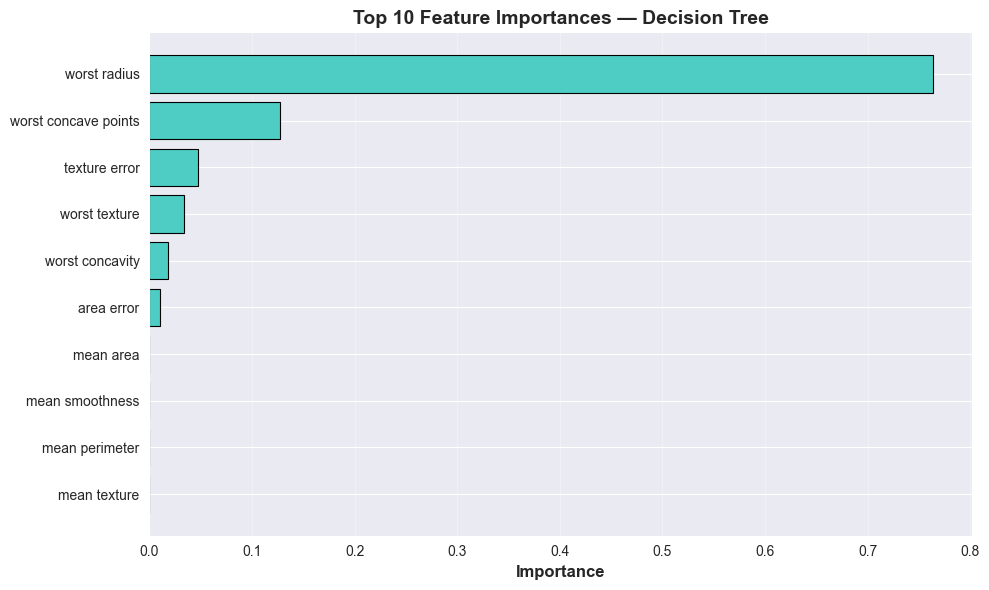

In [10]:
# Feature importance — which features does the tree use most?
importance_df = pd.DataFrame({
    'Feature': cancer.feature_names,
    'Importance': tree.feature_importances_
}).sort_values('Importance', ascending=True)

# Plot top 10
top10 = importance_df.tail(10)

plt.figure(figsize=(10, 6))
plt.barh(top10['Feature'], top10['Importance'], color='#4ECDC4',
         edgecolor='black', linewidth=0.8)
plt.xlabel('Importance', fontweight='bold', fontsize=12)
plt.title('Top 10 Feature Importances — Decision Tree', fontweight='bold', fontsize=14)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

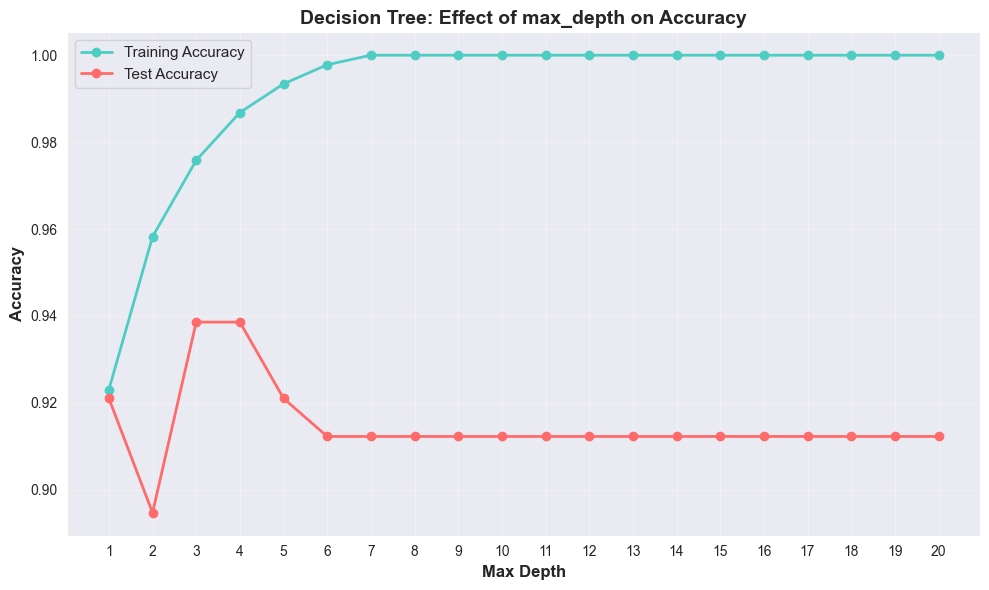


Best max_depth: 3 (test accuracy: 0.9386)
Notice: Training accuracy reaches 1.0 (perfect) with deep trees — that's OVERFITTING!


In [11]:
# How max_depth affects accuracy — overfitting demonstration
depths = range(1, 21)
train_accs = []
test_accs = []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_train, y_train)
    train_accs.append(dt.score(X_train, y_train))
    test_accs.append(dt.score(X_test, y_test))

plt.figure(figsize=(10, 6))
plt.plot(depths, train_accs, 'o-', color='#4ECDC4', linewidth=2, label='Training Accuracy')
plt.plot(depths, test_accs, 'o-', color='#FF6B6B', linewidth=2, label='Test Accuracy')
plt.xlabel('Max Depth', fontweight='bold', fontsize=12)
plt.ylabel('Accuracy', fontweight='bold', fontsize=12)
plt.title('Decision Tree: Effect of max_depth on Accuracy', fontweight='bold', fontsize=14)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.xticks(depths)
plt.tight_layout()
plt.show()

best_depth = depths[np.argmax(test_accs)]
print(f"\nBest max_depth: {best_depth} (test accuracy: {max(test_accs):.4f})")
print(f"Notice: Training accuracy reaches 1.0 (perfect) with deep trees — that's OVERFITTING!")

---
## 4. K-Nearest Neighbors (KNN)

KNN classifies a data point based on the majority class of its K nearest neighbors. It requires scaling!

In [12]:
# KNN requires scaled data
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)
print(f"KNN (k=5) Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}")

KNN (k=5) Accuracy: 0.9561


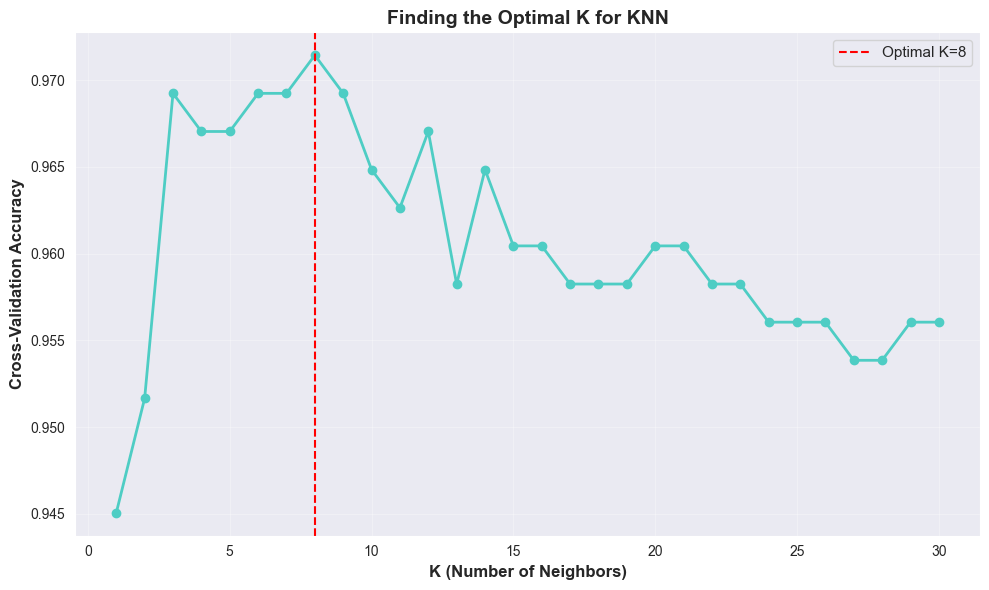

Optimal K: 8 (CV Accuracy: 0.9714)


In [13]:
# Find the optimal K
k_range = range(1, 31)
k_scores = []

for k in k_range:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn_temp, X_train_scaled, y_train, cv=5, scoring='accuracy')
    k_scores.append(scores.mean())

optimal_k = list(k_range)[np.argmax(k_scores)]

plt.figure(figsize=(10, 6))
plt.plot(k_range, k_scores, 'o-', color='#4ECDC4', linewidth=2)
plt.axvline(x=optimal_k, color='red', linestyle='--', linewidth=1.5, label=f'Optimal K={optimal_k}')
plt.xlabel('K (Number of Neighbors)', fontweight='bold', fontsize=12)
plt.ylabel('Cross-Validation Accuracy', fontweight='bold', fontsize=12)
plt.title('Finding the Optimal K for KNN', fontweight='bold', fontsize=14)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Optimal K: {optimal_k} (CV Accuracy: {max(k_scores):.4f})")

In [14]:
# Demonstrate the importance of scaling
knn_unscaled = KNeighborsClassifier(n_neighbors=optimal_k)
knn_unscaled.fit(X_train, y_train)  # NO scaling

knn_scaled = KNeighborsClassifier(n_neighbors=optimal_k)
knn_scaled.fit(X_train_scaled, y_train)  # WITH scaling

print(f"KNN Accuracy WITHOUT scaling: {knn_unscaled.score(X_test, y_test):.4f}")
print(f"KNN Accuracy WITH scaling:    {knn_scaled.score(X_test_scaled, y_test):.4f}")
print(f"\nScaling improves accuracy by {(knn_scaled.score(X_test_scaled, y_test) - knn_unscaled.score(X_test, y_test))*100:.1f} percentage points!")

KNN Accuracy WITHOUT scaling: 0.9298
KNN Accuracy WITH scaling:    0.9737

Scaling improves accuracy by 4.4 percentage points!


---
## 5. Model Comparison

Let's compare all three classifiers side by side.

In [15]:
# Train all models and compare
models = {
    'Logistic Regression': (LogisticRegression(max_iter=10000, random_state=42), X_train_scaled, X_test_scaled),
    'Decision Tree (depth=5)': (DecisionTreeClassifier(max_depth=5, random_state=42), X_train, X_test),
    f'KNN (k={optimal_k})': (KNeighborsClassifier(n_neighbors=optimal_k), X_train_scaled, X_test_scaled),
}

comparison_results = []

for name, (model, X_tr, X_te) in models.items():
    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)
    
    comparison_results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
    })

comp_df = pd.DataFrame(comparison_results).set_index('Model')
print("Model Comparison:")
comp_df.round(4)

Model Comparison:


,Accuracy,Precision,Recall,F1
Model,,,,
Logistic Regression,0.9825,0.9861,0.9861,0.9861
Decision Tree (depth=5),0.9211,0.9565,0.9167,0.9362
KNN (k=8),0.9737,0.9726,0.9861,0.9793


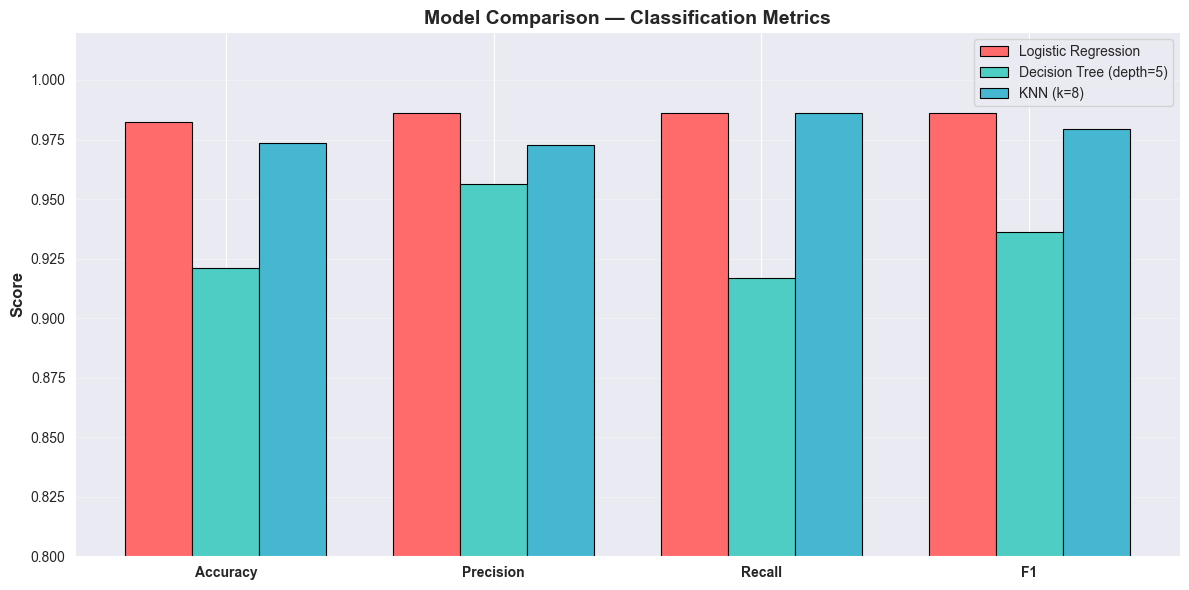

In [16]:
# Visualize comparison
fig, ax = plt.subplots(figsize=(12, 6))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
x = np.arange(len(metrics))
width = 0.25
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

for i, (idx, row) in enumerate(comp_df.iterrows()):
    bars = ax.bar(x + i * width, row[metrics].values, width,
                  label=idx, color=colors[i], edgecolor='black', linewidth=0.8)

ax.set_xticks(x + width)
ax.set_xticklabels(metrics, fontweight='bold')
ax.set_ylabel('Score', fontweight='bold', fontsize=12)
ax.set_title('Model Comparison — Classification Metrics', fontweight='bold', fontsize=14)
ax.legend(fontsize=10)
ax.set_ylim(0.8, 1.02)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

5-Fold Cross-Validation Comparison:
  Logistic Regression             0.9802 ± 0.0128
  Decision Tree (depth=5)         0.9319 ± 0.0213
  KNN (k=8)                       0.9714 ± 0.0192


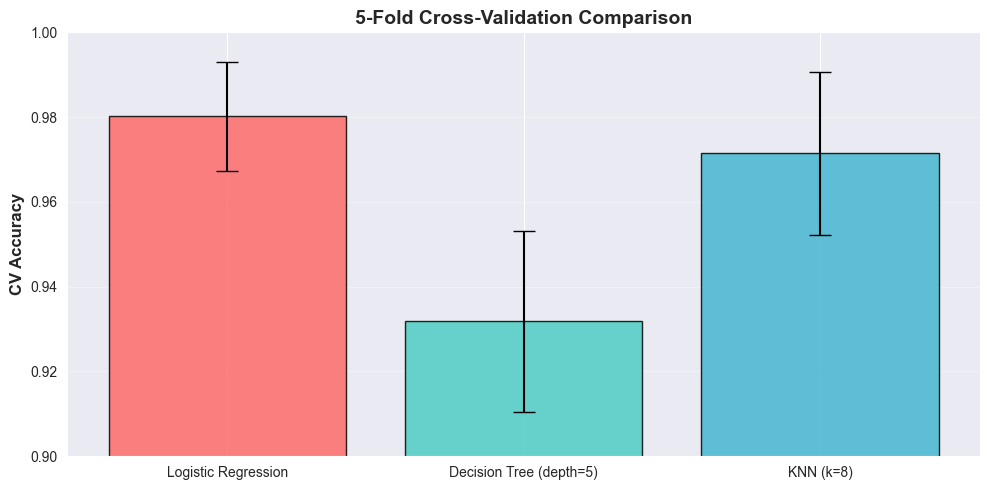

In [17]:
# Cross-validation comparison (more reliable than single split)
print("5-Fold Cross-Validation Comparison:")
print("=" * 55)

cv_models = {
    'Logistic Regression': LogisticRegression(max_iter=10000, random_state=42),
    'Decision Tree (depth=5)': DecisionTreeClassifier(max_depth=5, random_state=42),
    f'KNN (k={optimal_k})': KNeighborsClassifier(n_neighbors=optimal_k),
}

cv_results = []
for name, model in cv_models.items():
    # Use scaled data for all (trees don't need it but it doesn't hurt)
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')
    cv_results.append({'Model': name, 'Mean': scores.mean(), 'Std': scores.std()})
    print(f"  {name:30s}  {scores.mean():.4f} ± {scores.std():.4f}")

# Plot with error bars
cv_df = pd.DataFrame(cv_results)
plt.figure(figsize=(10, 5))
bars = plt.bar(cv_df['Model'], cv_df['Mean'], yerr=cv_df['Std'],
               capsize=8, color=colors, edgecolor='black', linewidth=1, alpha=0.85)
plt.ylabel('CV Accuracy', fontweight='bold', fontsize=12)
plt.title('5-Fold Cross-Validation Comparison', fontweight='bold', fontsize=14)
plt.grid(axis='y', alpha=0.3)
plt.ylim(0.9, 1.0)
plt.tight_layout()
plt.show()

---
## 6. Overfitting, Learning Curves & Cross-Validation

### 6.1 Learning Curves

Learning curves show how performance changes as we add more training data. They help diagnose underfitting and overfitting.

/Users/yashodperera/Documents/c-clark/ai_repo/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/yashodperera/Documents/c-clark/ai_repo/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/yashodperera/Documents/c-clark/ai_repo/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/yashodperera/Documents/c-clark/ai_repo/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/yashodperera/Documents/c-clark/ai_repo/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_los

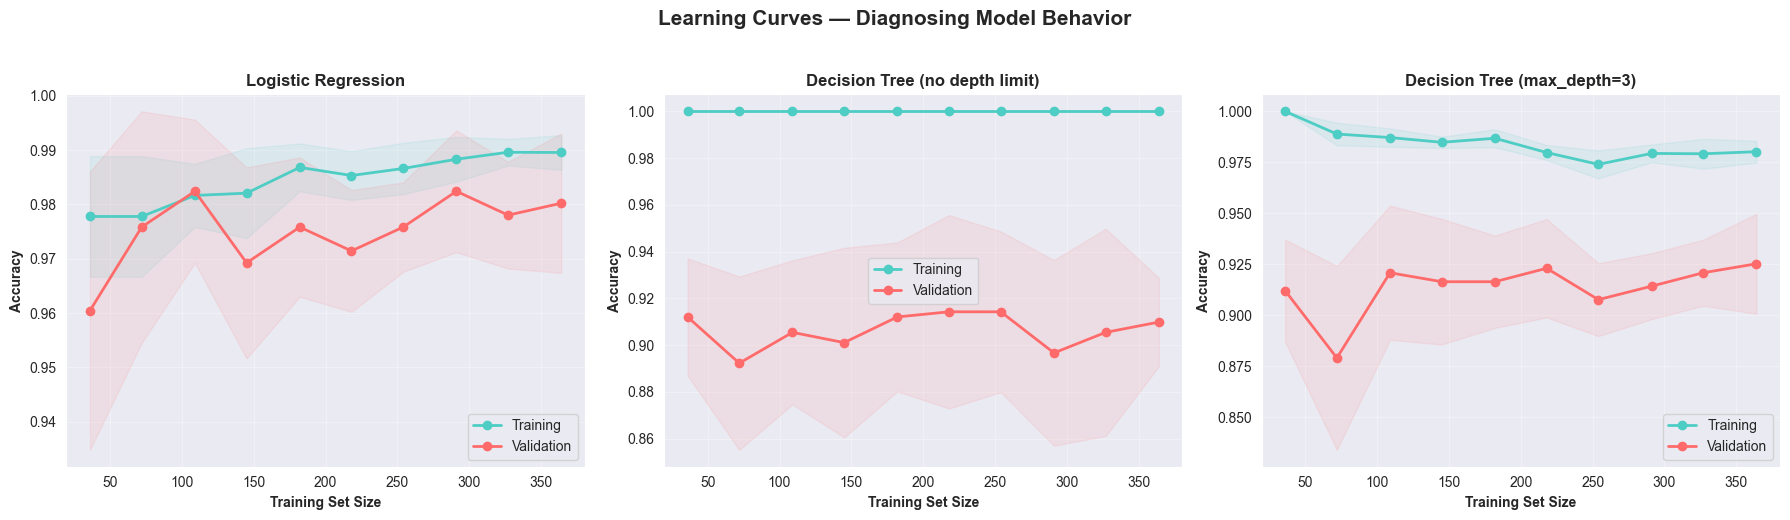

In [18]:
def plot_learning_curve(estimator, X, y, title, ax=None):
    """Plot learning curve showing training and validation accuracy."""
    train_sizes, train_scores, val_scores = learning_curve(
        estimator, X, y, cv=5, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='accuracy'
    )
    
    train_mean = train_scores.mean(axis=1)
    val_mean = val_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    val_std = val_scores.std(axis=1)
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))
    
    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='#4ECDC4')
    ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1, color='#FF6B6B')
    ax.plot(train_sizes, train_mean, 'o-', color='#4ECDC4', linewidth=2, label='Training')
    ax.plot(train_sizes, val_mean, 'o-', color='#FF6B6B', linewidth=2, label='Validation')
    ax.set_xlabel('Training Set Size', fontweight='bold')
    ax.set_ylabel('Accuracy', fontweight='bold')
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)
    return ax

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

plot_learning_curve(LogisticRegression(max_iter=10000), X_train_scaled, y_train,
                    'Logistic Regression', axes[0])
plot_learning_curve(DecisionTreeClassifier(max_depth=None, random_state=42), X_train, y_train,
                    'Decision Tree (no depth limit)', axes[1])
plot_learning_curve(DecisionTreeClassifier(max_depth=3, random_state=42), X_train, y_train,
                    'Decision Tree (max_depth=3)', axes[2])

plt.suptitle('Learning Curves — Diagnosing Model Behavior', fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

**How to read these learning curves:**

| Pattern | What it means | What to do |
|---------|--------------|------------|
| Both curves converge at HIGH value, small gap | Good fit | Ship it! |
| Training = 1.0 but validation much lower | Overfitting | Simplify, regularize, more data |
| Both curves LOW | Underfitting | More features, complex model |

---
## 7. The Precision-Recall Tradeoff

By adjusting the decision threshold (default = 0.5), we can trade precision for recall.

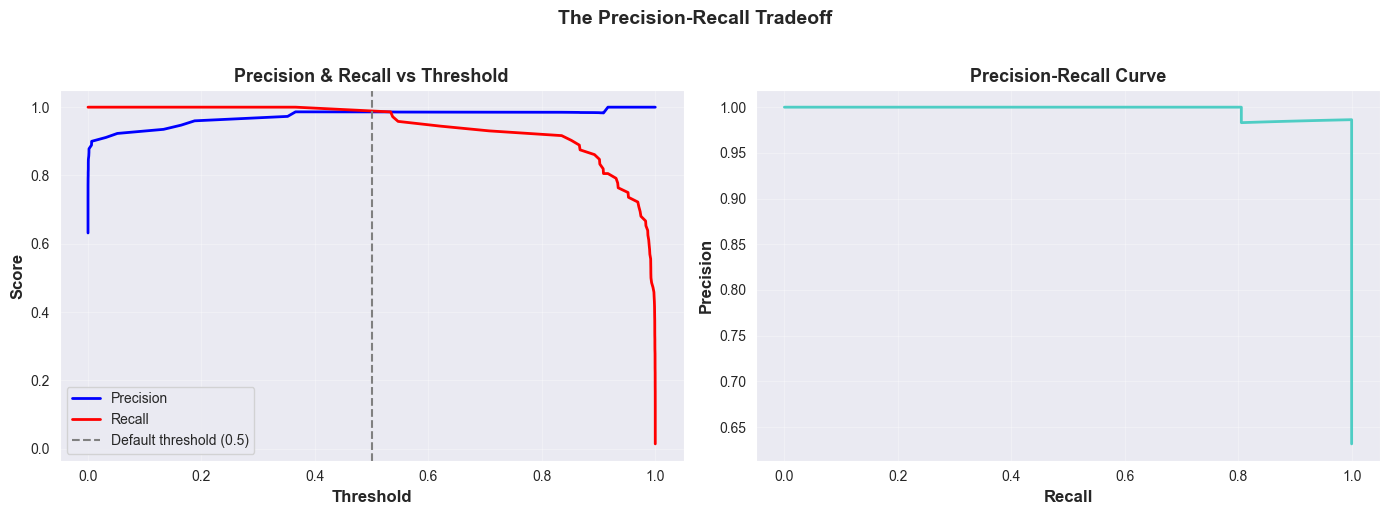

In [19]:
# Get probabilities for the positive class
y_scores = log_reg.predict_proba(X_test_scaled)[:, 1]

# Precision-Recall curve
precisions, recalls, thresholds_pr = precision_recall_curve(y_test, y_scores)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Precision and Recall vs Threshold
axes[0].plot(thresholds_pr, precisions[:-1], 'b-', linewidth=2, label='Precision')
axes[0].plot(thresholds_pr, recalls[:-1], 'r-', linewidth=2, label='Recall')
axes[0].axvline(x=0.5, color='gray', linestyle='--', label='Default threshold (0.5)')
axes[0].set_xlabel('Threshold', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Score', fontweight='bold', fontsize=12)
axes[0].set_title('Precision & Recall vs Threshold', fontweight='bold', fontsize=13)
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

# Precision-Recall curve
axes[1].plot(recalls, precisions, color='#4ECDC4', linewidth=2)
axes[1].set_xlabel('Recall', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Precision', fontweight='bold', fontsize=12)
axes[1].set_title('Precision-Recall Curve', fontweight='bold', fontsize=13)
axes[1].grid(alpha=0.3)

plt.suptitle('The Precision-Recall Tradeoff', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [20]:
# Show how different thresholds change predictions
print("Effect of changing the decision threshold:")
print("=" * 65)
for threshold in [0.3, 0.5, 0.7, 0.9]:
    y_pred_thresh = (y_scores >= threshold).astype(int)
    prec = precision_score(y_test, y_pred_thresh)
    rec = recall_score(y_test, y_pred_thresh)
    f1 = f1_score(y_test, y_pred_thresh)
    print(f"  Threshold={threshold:.1f}:  Precision={prec:.3f}  Recall={rec:.3f}  F1={f1:.3f}")

print("\nLower threshold = more positives = higher recall but lower precision")
print("Higher threshold = fewer positives = higher precision but lower recall")

Effect of changing the decision threshold:
  Threshold=0.3:  Precision=0.973  Recall=1.000  F1=0.986
  Threshold=0.5:  Precision=0.986  Recall=0.986  F1=0.986
  Threshold=0.7:  Precision=0.985  Recall=0.931  F1=0.957
  Threshold=0.9:  Precision=0.984  Recall=0.847  F1=0.910

Lower threshold = more positives = higher recall but lower precision
Higher threshold = fewer positives = higher precision but lower recall


---
## 8. Practice Exercises

### Exercise 1: Iris Classification
Load the Iris dataset, build a logistic regression model, and evaluate with a confusion matrix.

In [21]:
# Exercise 1: Your code here
iris = load_iris()

# Step 1: Train/test split
# X_train_i, X_test_i, y_train_i, y_test_i = ...

# Step 2: Fit LogisticRegression
# ...

# Step 3: Create confusion matrix heatmap
# Hint: use sns.heatmap with target_names=['setosa', 'versicolor', 'virginica']
# ...

### Exercise 2: Decision Tree on Iris
Build a decision tree on the Iris dataset. What is the most important feature?

In [22]:
# Exercise 2: Your code here
# Step 1: Fit DecisionTreeClassifier(max_depth=3)
# Step 2: Print feature importances
# Step 3: Visualize the tree with plot_tree
# ...

### Exercise 3: Titanic Classification Challenge
Use the Titanic dataset from seaborn. Preprocess and compare logistic regression vs decision tree with 10-fold CV.

In [23]:
# Exercise 3: Your code here
titanic = sns.load_dataset('titanic').dropna(subset=['age', 'fare', 'embarked'])

# Step 1: Select features: pclass, age, fare, sibsp, parch
# Step 2: Target: survived
# Step 3: Train/test split (stratified)
# Step 4: Scale features
# Step 5: Fit Logistic Regression and Decision Tree
# Step 6: Compare with 10-fold cross-validation
# ...

### Exercise 4: Optimal Threshold
For the breast cancer dataset, what threshold maximizes the F1 score for detecting malignant tumors?

In [24]:
# Exercise 4: Your code here
# Hint: Loop through thresholds from 0.1 to 0.9
# For each threshold, calculate F1 score with pos_label=0
# Find the threshold that gives the best F1
# ...

---
## Key Takeaways

| Concept | What We Learned |
|---------|----------------|
| **Logistic Regression** | Sigmoid squishes scores to probabilities → threshold → class |
| **Decision Trees** | Learns if/else rules, interpretable, prone to overfitting |
| **KNN** | Finds K nearest neighbors, needs scaling, no training phase |
| **Confusion Matrix** | Shows TP, TN, FP, FN — reveals where the model fails |
| **Accuracy** | Can be misleading with imbalanced data |
| **Precision** | "When I predict positive, am I right?" |
| **Recall** | "Of all actual positives, how many did I find?" |
| **F1 Score** | Harmonic mean — balance of precision and recall |
| **ROC/AUC** | Overall classifier quality (0.5 = random, 1.0 = perfect) |
| **Learning Curves** | Diagnose underfitting (both high) vs overfitting (big gap) |
| **Cross-Validation** | K-Fold for reliable estimates; stratified for classification |

**Next up (Day 3):** SVM, ensemble methods, hyperparameter tuning, and a complete ML pipeline!